<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB7(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

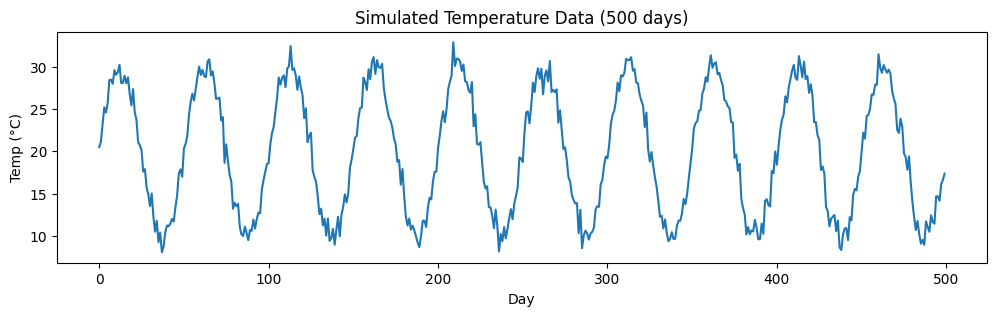

In [ ]:
# Generate 500 days of fake temperature data
np.random.seed(42)
time = np.arange(500)
temperature = 20 + 10 * np.sin(2 * np.pi * time / 50) + np.random.normal(0, 1, 500)

# Plot it
plt.figure(figsize=(12, 3))
plt.plot(temperature)
plt.title("Simulated Temperature Data (500 days)")
plt.xlabel("Day"); plt.ylabel("Temp (°C)")
plt.show()

In [ ]:
window = 10   # use past 10 days to predict next day

X, y = [], []
for i in range(len(temperature) - window):
    X.append(temperature[i : i + window])
    y.append(temperature[i + window])

X = np.array(X).reshape(-1, window, 1)  # shape: (samples, timesteps, features)
y = np.array(y)

# Train / test split (80 / 20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)   # e.g. (392, 10, 1)
print("y_train shape:", y_train.shape)   # e.g. (392,)

X_train shape: (392, 10, 1)
y_train shape: (392,)


In [ ]:
model = models.Sequential([
    layers.SimpleRNN(32, activation='tanh', input_shape=(window, 1)),
    layers.Dense(1)   # output: one predicted temperature value
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 435.0231 - val_loss: 356.8877
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 409.8651 - val_loss: 333.2761
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 382.1253 - val_loss: 305.8356
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 352.5838 - val_loss: 282.6458
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 330.6748 - val_loss: 265.3022
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 312.7807 - val_loss: 247.9434
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 291.9876 - val_loss: 227.6050
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 271.0068 - val_loss: 211.1237
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 252.9931 - val_loss: 195.1174
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 234.7546 - val_loss: 179.0547
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 216.1221 - val_loss: 165.3722
Epoch 12/20
11/11 ━

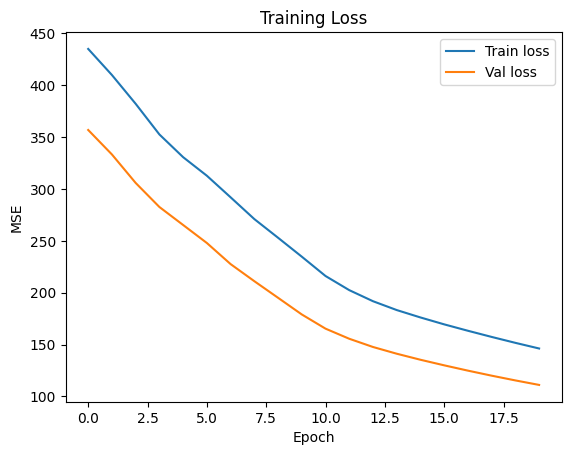

In [ ]:
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title("Training Loss"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step


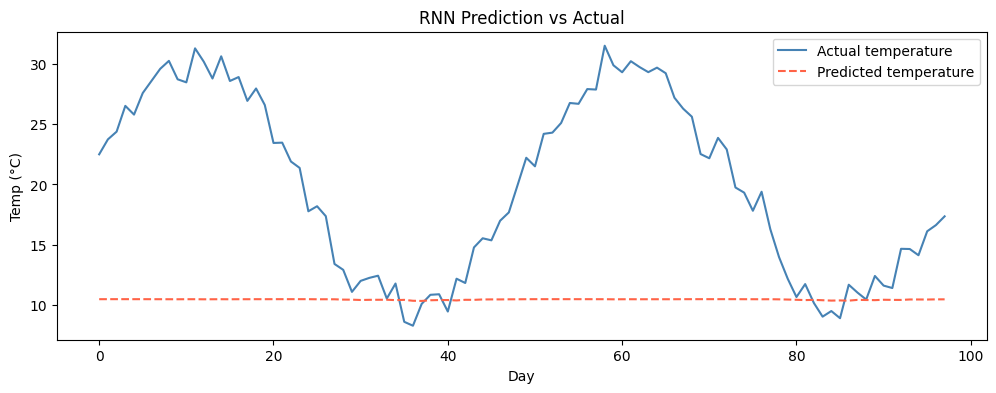

In [ ]:
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_test,  label='Actual temperature',    color='steelblue')
plt.plot(y_pred,  label='Predicted temperature', color='tomato', linestyle='--')
plt.title("RNN Prediction vs Actual")
plt.xlabel("Day"); plt.ylabel("Temp (°C)")
plt.legend(); plt.show()

In [ ]:
mae = np.mean(np.abs(y_pred - y_test))
print(f"Mean Absolute Error: {mae:.2f} °C")

Mean Absolute Error: 9.65 °C
